### PH464/564: Scientific Computing II
___

# Homework 6
### Due: Mon, Dec 1st at 11:59pm Pacific
---

# Identifying M4 cluster members w/ Dense Neural Networks

_NOTE_: I don't include the data here to keep things small. Please get the data from the class repo.

Demonstrate the use of a densely connected neural network, like the one we trained on the MNIST data set, for classifying stars in the M4 cluster using Gaia's measurements of stars' locations on the sky (right ascension and declination). This is basically a repeat of what we covered in class, but this time I want you to even out the training set to include roughly equal numbers of M4 members and non-members.

1. What training and validation accuracies are you able to achieve?

2. Is your trained model confident that any of the stars in your test set are part of M4?

3. What did your model learn? Can you come up with a useful way to probe your model and visualize the results to answer this question?

4. Do you think more sophisticated models could do better with this classification task using only sky positions? Use the properties of the training set to make your argument.

**564 students:**

Make use of other features observed by Gaia to improve your classifier. Be sure to use the data model documentation to understand what each feature is, and explain why you think it would be useful for identifying cluster members. What training and validation accuracies can you achieve? Does your trained model find any stars it believes are confidently in M4 that weren't in the M4 catalog?

In [1]:
import numpy as np

import jax
import jax.numpy as jnp

import pandas as pd
import matplotlib.pyplot as plt

from flax import linen as nn

In [2]:
import matplotlib
matplotlib.rcParams['font.family'] = "serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"
font = {'size' : 14}
plt.rc('font', **font)

In [3]:
m4_df = pd.read_fwf('../data/NGC6121-1.dat', names=['source_id', 'ra', 'dec', 'phot_g_mean_mag'])
m4_df

,source_id,ra,dec,phot_g_mean_mag
0,6045504229661220736,245.99162,-26.34434,18.438
1,6045504981264184192,246.03035,-26.28057,18.769
2,6045508902585952640,245.88761,-26.24297,19.072
3,6045507180287440000,245.85343,-26.28453,18.495
4,6045503473747038464,245.87124,-26.34628,17.163
...,...,...,...,...
19503,6045337962873610240,245.13976,-27.09970,19.705
19504,6045298891556291712,245.48339,-27.19208,19.493
19505,6045305866578950784,245.69445,-27.06942,18.290
19506,6045303774938119808,245.80824,-27.07275,19.267


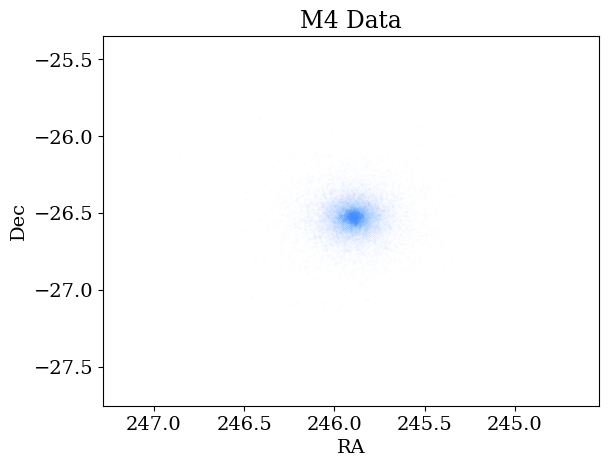

In [4]:
plt.scatter(m4_df.ra, m4_df.dec, s=0.0001, color='dodgerblue')
plt.title('M4 Data')
plt.xlabel('RA')
plt.ylabel('Dec')
plt.gca().invert_xaxis()

In [5]:
df = pd.read_csv('../../hub_data_share/m4_gaia_source.csv')
df.head()

,designation,source_id,ra,dec,parallax,parallax_error,parallax_over_error,pm,pmra,pmra_error,...,phot_g_mean_flux_over_error,phot_g_mean_mag,phot_bp_mean_flux_over_error,phot_bp_mean_mag,phot_rp_mean_flux_over_error,phot_rp_mean_mag,phot_bp_rp_excess_factor,bp_rp,radial_velocity,radial_velocity_error
0,Gaia DR3 6048466004733106048,6048466004733106048,244.500044,-26.152984,2.274643,1.125653,2.020732,8.490148,-7.892926,1.880442,...,110.199646,20.722200,4.511861,21.159956,17.483234,19.606243,1.661088,1.553713,NaN,NaN
1,Gaia DR3 6048666665606296064,6048666665606296064,244.500060,-25.906141,0.632528,0.769472,0.822029,2.582879,-0.097646,0.931963,...,178.075440,20.311983,10.519053,21.239437,20.069353,19.297583,1.380115,1.941855,NaN,NaN
2,Gaia DR3 6048358561832132864,6048358561832132864,244.500066,-26.918531,1.153917,0.907036,1.272184,7.455110,-5.327529,1.236975,...,152.003370,20.567377,7.892730,21.225716,16.701073,19.618095,1.404567,1.607620,NaN,NaN
3,Gaia DR3 6048842759265408128,6048842759265408128,244.500077,-25.216618,NaN,NaN,NaN,NaN,NaN,NaN,...,68.553120,20.875511,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Gaia DR3 6048837635368203648,6048837635368203648,244.500085,-25.318745,0.405547,0.118409,3.424970,1.204035,-0.644142,0.158066,...,959.558700,17.849728,73.395320,18.590256,129.001560,16.973124,1.310396,1.617132,NaN,NaN


In [6]:
df.columns

Index(['designation', 'source_id', 'ra', 'dec', 'parallax', 'parallax_error',
       'parallax_over_error', 'pm', 'pmra', 'pmra_error', 'pmdec',
       'pmdec_error', 'astrometric_n_good_obs_al', 'astrometric_chi2_al',
       'visibility_periods_used', 'phot_g_mean_flux_over_error',
       'phot_g_mean_mag', 'phot_bp_mean_flux_over_error', 'phot_bp_mean_mag',
       'phot_rp_mean_flux_over_error', 'phot_rp_mean_mag',
       'phot_bp_rp_excess_factor', 'bp_rp', 'radial_velocity',
       'radial_velocity_error'],
      dtype='object')

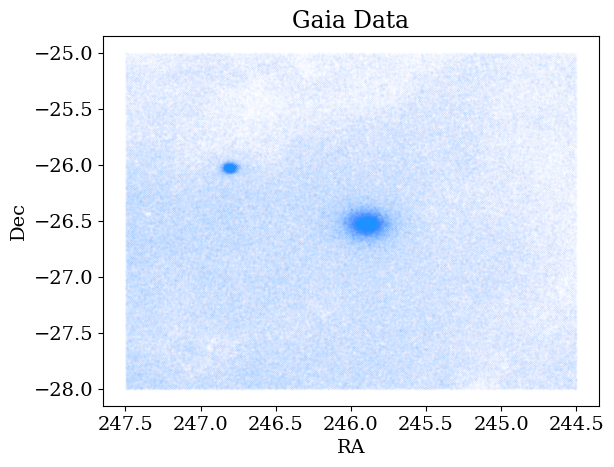

In [7]:
plt.scatter(df.ra, df.dec, s=0.0001, color='dodgerblue')
plt.title('Gaia Data')
plt.xlabel('RA')
plt.ylabel('Dec')
plt.gca().invert_xaxis()

In [8]:
m4_sel = df['source_id'].isin(m4_df.source_id)
print(np.count_nonzero(m4_sel))
print(np.count_nonzero(~m4_sel))

19084
475912


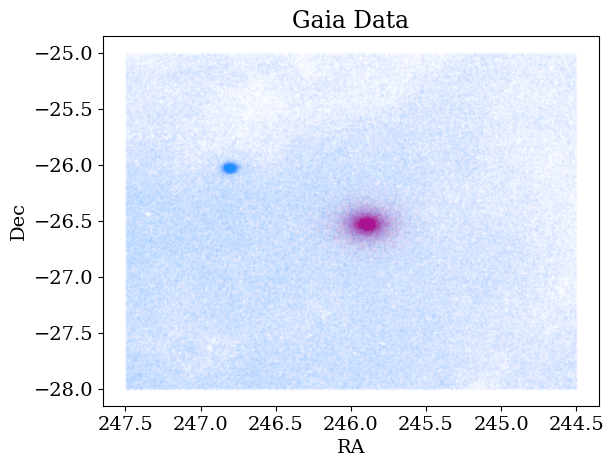

In [9]:
plt.scatter(df.ra[~m4_sel], df.dec[~m4_sel], s=0.0001, color='dodgerblue', label='Non M4 Members')
plt.scatter(df.ra[m4_sel], df.dec[m4_sel], s=0.0001, color='deeppink', label='M4 Members')
plt.title('Gaia Data')
plt.xlabel('RA')
plt.ylabel('Dec')
plt.gca().invert_xaxis()

In [10]:
params = ['ra', 'dec']
X_full = np.array(df[params])
y_full = m4_sel.astype(int)

nans = np.any(np.isnan(X_full), axis=1)
X_full = X_full[~nans]
y_full = y_full[~nans]

m4_mask = y_full == 1
non_mask = y_full == 0

X_m4 = np.array(X_full[m4_mask])
y_m4 = np.array(y_full[m4_mask])
X_non = np.array(X_full[non_mask])
y_non = np.array(y_full[non_mask])

n = X_m4.shape[0]
idx = np.random.choice(X_non.shape[0], size=n, replace=False)

X_non = X_non[idx]
y_non = y_non[idx]

X = np.concatenate((X_m4, X_non))
y = np.concatenate((y_m4, y_non))

print(X.shape, y.shape)

(38168, 2) (38168,)


In [11]:
from sklearn.model_selection import train_test_split

indices = np.arange(X.shape[0])
X_train, X_tst, y_train, y_tst, train_idx, test_idx = train_test_split(X, y, indices, test_size=0.1, shuffle=True, random_state=42)

In [12]:
from sklearn.preprocessing import StandardScaler

In [13]:
transformer = StandardScaler()

X_train = transformer.fit_transform(X_train)
X_tst = transformer.transform(X_tst)

In [14]:
X_train = jnp.array(X_train)
X_tst = jnp.array(X_tst)
y_train = jnp.array(y_train)
y_tst = jnp.array(y_tst)

In [15]:
batch_size = 64
n_batches = X_train.shape[0] // batch_size

X_train = X_train[:n_batches * batch_size].reshape((n_batches, batch_size, *X_train.shape[1:]))
y_train = y_train[:n_batches * batch_size].reshape((n_batches, batch_size, *y_train.shape[1:]))
X_train.shape, y_train.shape

((536, 64, 2), (536, 64))

In [16]:
n_classes = 2

class DenseClassifier(nn.Module):
    """A simple dense classifier."""

    @nn.compact
    def __call__(self, x):
        x = nn.Dense(10)(x)
        x = nn.relu(x)
        x = nn.Dense(10)(x)
        x = nn.relu(x)
        x = nn.Dense(n_classes)(x)
        return x

In [17]:
dummy_input = jnp.ones((1, 2))
dnn = DenseClassifier()
print(dnn.tabulate(jax.random.PRNGKey(0), dummy_input))


                            DenseClassifier Summary                             
┏━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃ path    ┃ module          ┃ inputs        ┃ outputs       ┃ params           ┃
┡━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│         │ DenseClassifier │ float32[1,2]  │ float32[1,2]  │                  │
├─────────┼─────────────────┼───────────────┼───────────────┼──────────────────┤
│ Dense_0 │ Dense           │ float32[1,2]  │ float32[1,10] │ bias:            │
│         │                 │               │               │ float32[10]      │
│         │                 │               │               │ kernel:          │
│         │                 │               │               │ float32[2,10]    │
│         │                 │               │               │                  │
│         │                 │               │               │ 30 (120 B)       │
├─────────┼────────────────

In [18]:
X_train.shape, y_train.shape

((536, 64, 2), (536, 64))

In [19]:
from clu import metrics
from flax.training import train_state
from flax import struct
import optax

In [20]:
@struct.dataclass
class Metrics(metrics.Collection):
    accuracy: metrics.Accuracy
    loss: metrics.Average.from_output('loss')

class TrainState(train_state.TrainState):
   metrics: Metrics

In [21]:
def create_train_state(model, rng, learning_rate):
    params = model.init(rng, dummy_input)['params']
    tx = optax.adam(learning_rate)
    return TrainState.create(
        apply_fn=model.apply, params=params, tx=tx,
        metrics=Metrics.empty())

In [22]:
@jax.jit
def train_step(state, batch, label):
  """Train for a single step."""
  def loss_fn(params):
    logits = state.apply_fn({'params': params}, batch)
    loss = optax.softmax_cross_entropy_with_integer_labels(
        logits=logits, labels=label).mean()
    return loss
  grad_fn = jax.grad(loss_fn)
  grads = grad_fn(state.params)
  state = state.apply_gradients(grads=grads)
  return state

In [23]:
@jax.jit
def compute_metrics(*, state, batch, label):
    logits = state.apply_fn({'params': state.params}, batch)
    loss = optax.softmax_cross_entropy_with_integer_labels(
        logits=logits, labels=label).mean()
    metric_updates = state.metrics.single_from_model_output(
        logits=logits, labels=label, loss=loss)
    metrics = state.metrics.merge(metric_updates)
    state = state.replace(metrics=metrics)
    return state

In [24]:
init_rng = jax.random.PRNGKey(0)

learning_rate = 0.01

state = create_train_state(dnn, init_rng, learning_rate)
del init_rng  # Must not be used anymore.

In [25]:
metrics_history = {'train_loss': [],
                   'train_accuracy': [],
                   'test_loss': [],
                   'test_accuracy': []}

In [26]:
n_epochs = 50

In [27]:
step = 0

for _ in range(n_epochs):
  for batch, label in zip(X_train, y_train):

    # Run optimization steps over training batches and compute batch metrics
    state = train_step(state, batch, label) # get updated train state (which contains the updated parameters)
    state = compute_metrics(state=state, batch=batch, label=label) # aggregate batch metrics

    if (step+1) % n_batches == 0: # one training epoch has passed
      for metric,value in state.metrics.compute().items(): # compute metrics
        metrics_history[f'train_{metric}'].append(value) # record metrics
      state = state.replace(metrics=state.metrics.empty()) # reset train_metrics for next training epoch

      # Compute metrics on the test set after each training epoch
      test_state = state
      test_state = compute_metrics(state=test_state, batch=X_tst, label=y_tst)

      for metric,value in test_state.metrics.compute().items():
        metrics_history[f'test_{metric}'].append(value)

      print(f"train epoch: {(step+1) // n_batches}, "
            f"loss: {metrics_history['train_loss'][-1]}, "
            f"accuracy: {metrics_history['train_accuracy'][-1] * 100}")
      print(f"test epoch: {(step+1) // n_batches}, "
            f"loss: {metrics_history['test_loss'][-1]}, "
            f"accuracy: {metrics_history['test_accuracy'][-1] * 100}")
    step += 1

train epoch: 1, loss: 0.2137453407049179, accuracy: 92.76760864257812
test epoch: 1, loss: 0.2042391002178192, accuracy: 92.90017700195312
train epoch: 2, loss: 0.2019212245941162, accuracy: 93.12616729736328
test epoch: 2, loss: 0.20328302681446075, accuracy: 92.87398529052734
train epoch: 3, loss: 0.20145180821418762, accuracy: 93.1349105834961
test epoch: 3, loss: 0.2031351923942566, accuracy: 93.00497436523438
train epoch: 4, loss: 0.20107628405094147, accuracy: 93.14657592773438
test epoch: 4, loss: 0.20287878811359406, accuracy: 93.08357238769531
train epoch: 5, loss: 0.20091886818408966, accuracy: 93.13782501220703
test epoch: 5, loss: 0.20268957316875458, accuracy: 92.9787826538086
train epoch: 6, loss: 0.2007116675376892, accuracy: 93.16697692871094
test epoch: 6, loss: 0.20238898694515228, accuracy: 93.057373046875
train epoch: 7, loss: 0.2005143165588379, accuracy: 93.15823364257812
test epoch: 7, loss: 0.20227091014385223, accuracy: 93.08357238769531
train epoch: 8, loss: 0

In [28]:
print('Mean training accuracy: %.3f' % np.mean(metrics_history['train_accuracy']))
print('Mean testing accuracy: %.3f' % np.mean(metrics_history['test_accuracy']))

Mean training accuracy: 0.932
Mean testing accuracy: 0.932


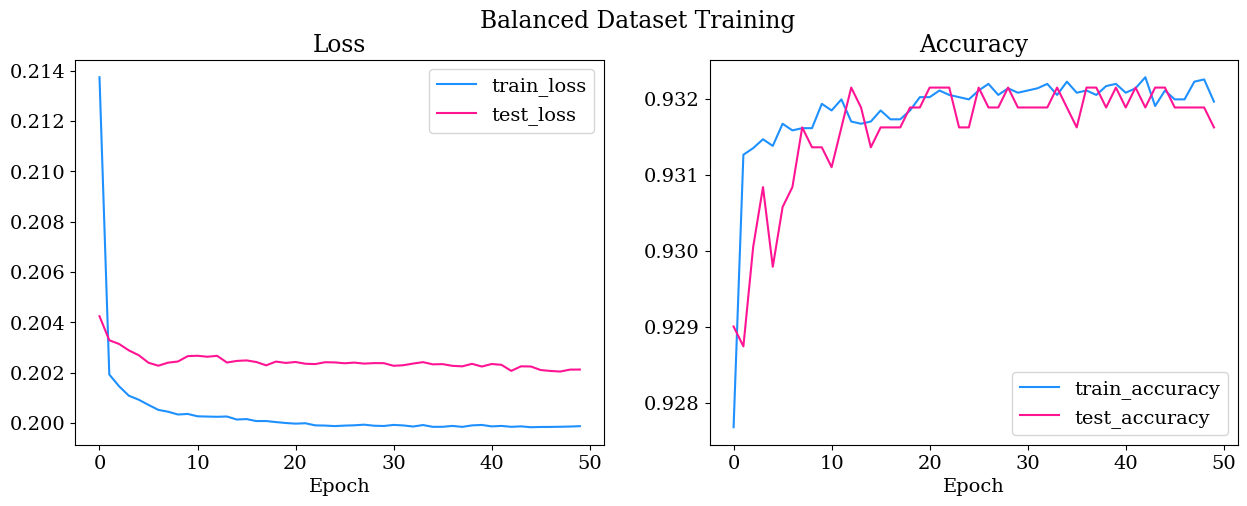

<Figure size 640x480 with 0 Axes>

In [29]:
# Plot loss and accuracy in subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Balanced Dataset Training')
ax1.set_title('Loss')
ax2.set_title('Accuracy')
colors = {
    'train': 'dodgerblue',
    'test': 'deeppink'
}
for dataset in ('train','test'):
  ax1.plot(metrics_history[f'{dataset}_loss'], label=f'{dataset}_loss', color=colors[dataset])
  ax2.plot(metrics_history[f'{dataset}_accuracy'], label=f'{dataset}_accuracy', color=colors[dataset])
ax1.set_xlabel('Epoch')
ax2.set_xlabel('Epoch')
ax1.legend()
ax2.legend()
plt.show()
plt.clf()

In [30]:
@jax.jit
def pred_step(state, batch):
  logits = state.apply_fn({'params': state.params}, batch)
  return logits.argmax(axis=1)

pred = pred_step(state, X_tst)
pred

Array([1, 1, 1, ..., 0, 1, 0], dtype=int32)

(array([1806.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
        2011.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

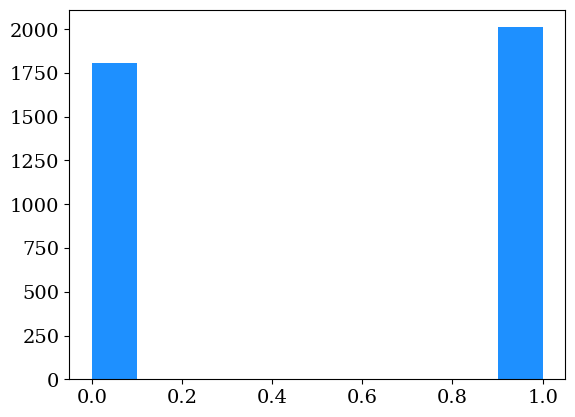

In [31]:
plt.hist(pred, color='dodgerblue')

Text(0.5, 0, 'Logit Value')

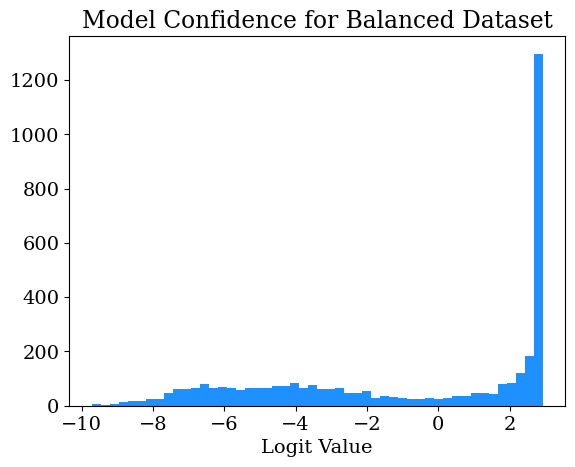

In [32]:
outputs = state.apply_fn({'params': state.params}, X_tst)
plt.hist(jnp.diff(outputs, axis=1).flatten(), color='dodgerblue', bins=50);
plt.title('Model Confidence for Balanced Dataset')
plt.xlabel('Logit Value')
# plt.xlim(-20,5)

In [33]:
logit = jnp.diff(outputs, axis=1).flatten()
print('Number of positive logits:', jnp.sum(logit > 0))

Number of positive logits: 2011


In [34]:
ra_full  = df['ra'][~nans].to_numpy()
dec_full = df['dec'][~nans].to_numpy()

ra_m4 = np.array(ra_full[m4_mask])
ra_non = np.array(ra_full[non_mask])
ra_non = ra_non[idx]

dec_m4 = np.array(dec_full[m4_mask])
dec_non = np.array(dec_full[non_mask])
dec_non = dec_non[idx]

ra = np.concatenate((ra_m4, ra_non))
dec = np.concatenate((dec_m4, dec_non))

print(ra.shape, dec.shape)

(38168,) (38168,)


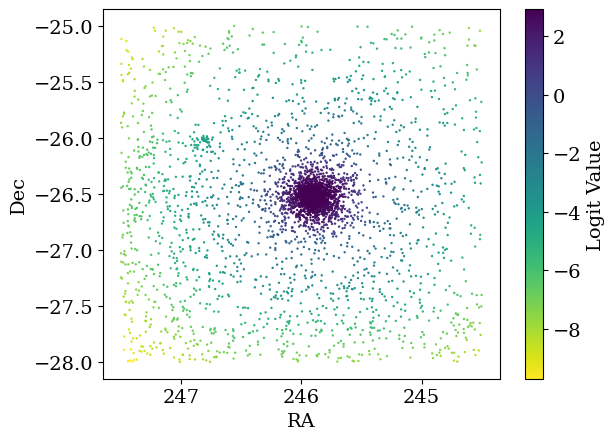

In [35]:
plt.scatter(ra[test_idx], dec[test_idx], c=jnp.diff(outputs, axis=1), s=0.5, cmap='viridis_r')
# plt.title('Balanced Dataset')
plt.xlabel('RA')
plt.ylabel('Dec')
plt.gca().invert_xaxis()
plt.colorbar(label='Logit Value')

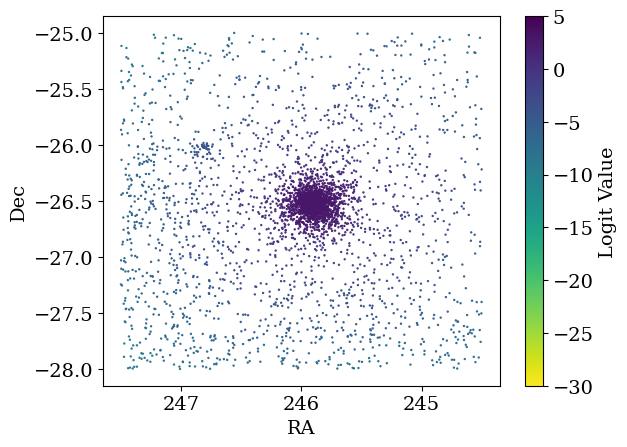

In [36]:
plt.scatter(ra[test_idx], dec[test_idx], c=jnp.diff(outputs, axis=1), s=0.5, cmap='viridis_r', vmin=-30, vmax=5)
# plt.title('Balanced Dataset')
plt.xlabel('RA')
plt.ylabel('Dec')
plt.gca().invert_xaxis()
plt.colorbar(label='Logit Value')

In [37]:
def check(state, batch, labels):
    logits = state.apply_fn({'params': state.params}, batch)
    pred = jnp.argmax(logits, axis=1)

    ncats = 2

    confusion_matrix = np.zeros((ncats, ncats))

    for truth, guess in zip(labels, pred):
        confusion_matrix[int(truth), int(guess)] += 1
        
    print("Confusion Matrix:\n", confusion_matrix)

    plt.imshow(confusion_matrix, cmap="RdPu")
    plt.colorbar()
    plt.xlabel("Prediction")
    plt.ylabel("Truth")
    plt.xticks([0, 1], ["non-M4", "M4"])
    plt.yticks([0, 1], ["non-M4", "M4"])
    plt.show()

Confusion Matrix:
 [[1720.  175.]
 [  86. 1836.]]


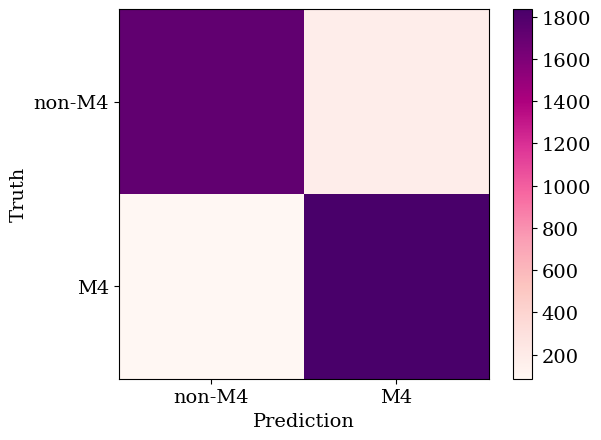

In [38]:
cm = check(state, X_tst, y_tst)

## 564 Problem

### Including Proper Motion

In [39]:
params = ['ra', 'dec', 'pmra', 'pmdec']
X_full = np.array(df[params])
y_full = m4_sel.astype(int)

nans = np.any(np.isnan(X_full), axis=1)
X_full = X_full[~nans]
y_full = y_full[~nans]

m4_mask = y_full == 1
non_mask = y_full == 0

X_m4 = np.array(X_full[m4_mask])
y_m4 = np.array(y_full[m4_mask])
X_non = np.array(X_full[non_mask])
y_non = np.array(y_full[non_mask])

n = X_m4.shape[0]
idx = np.random.choice(X_non.shape[0], size=n, replace=False)

X_non = X_non[idx]
y_non = y_non[idx]

X = np.concatenate((X_m4, X_non))
y = np.concatenate((y_m4, y_non))

print(X.shape, y.shape)

(38038, 4) (38038,)


In [40]:
indices = np.arange(X.shape[0])
X_train, X_tst, y_train, y_tst, train_idx, test_idx = train_test_split(X, y, indices, test_size=0.1, shuffle=True, random_state=42)

In [41]:
transformer = StandardScaler()

X_train = transformer.fit_transform(X_train)
X_tst = transformer.transform(X_tst)

In [42]:
X_train = jnp.array(X_train)
X_tst = jnp.array(X_tst)
y_train = jnp.array(y_train)
y_tst = jnp.array(y_tst)

In [43]:
batch_size = 64
n_batches = X_train.shape[0] // batch_size

X_train = X_train[:n_batches * batch_size].reshape((n_batches, batch_size, *X_train.shape[1:]))
y_train = y_train[:n_batches * batch_size].reshape((n_batches, batch_size, *y_train.shape[1:]))
X_train.shape, y_train.shape

((534, 64, 4), (534, 64))

In [44]:
n_classes = 2

class DenseClassifier(nn.Module):
    """A simple dense classifier."""

    @nn.compact
    def __call__(self, x):
        x = nn.Dense(10)(x)
        x = nn.relu(x)
        x = nn.Dense(10)(x)
        x = nn.relu(x)
        x = nn.Dense(n_classes)(x)
        return x

In [45]:
dummy_input = jnp.ones((1, 4))
dnn = DenseClassifier()
print(dnn.tabulate(jax.random.PRNGKey(0), dummy_input))


                            DenseClassifier Summary                             
┏━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃ path    ┃ module          ┃ inputs        ┃ outputs       ┃ params           ┃
┡━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│         │ DenseClassifier │ float32[1,4]  │ float32[1,2]  │                  │
├─────────┼─────────────────┼───────────────┼───────────────┼──────────────────┤
│ Dense_0 │ Dense           │ float32[1,4]  │ float32[1,10] │ bias:            │
│         │                 │               │               │ float32[10]      │
│         │                 │               │               │ kernel:          │
│         │                 │               │               │ float32[4,10]    │
│         │                 │               │               │                  │
│         │                 │               │               │ 50 (200 B)       │
├─────────┼────────────────

In [46]:
X_train.shape, y_train.shape

((534, 64, 4), (534, 64))

In [47]:
@struct.dataclass
class Metrics(metrics.Collection):
    accuracy: metrics.Accuracy
    loss: metrics.Average.from_output('loss')

class TrainState(train_state.TrainState):
   metrics: Metrics

In [48]:
def create_train_state(model, rng, learning_rate):
    params = model.init(rng, dummy_input)['params']
    tx = optax.adam(learning_rate)
    return TrainState.create(
        apply_fn=model.apply, params=params, tx=tx,
        metrics=Metrics.empty())

In [49]:
@jax.jit
def train_step(state, batch, label):
  """Train for a single step."""
  def loss_fn(params):
    logits = state.apply_fn({'params': params}, batch)
    loss = optax.softmax_cross_entropy_with_integer_labels(
        logits=logits, labels=label).mean()
    return loss
  grad_fn = jax.grad(loss_fn)
  grads = grad_fn(state.params)
  state = state.apply_gradients(grads=grads)
  return state

In [50]:
@jax.jit
def compute_metrics(*, state, batch, label):
    logits = state.apply_fn({'params': state.params}, batch)
    loss = optax.softmax_cross_entropy_with_integer_labels(
        logits=logits, labels=label).mean()
    metric_updates = state.metrics.single_from_model_output(
        logits=logits, labels=label, loss=loss)
    metrics = state.metrics.merge(metric_updates)
    state = state.replace(metrics=metrics)
    return state

In [51]:
init_rng = jax.random.PRNGKey(0)

learning_rate = 0.01

state = create_train_state(dnn, init_rng, learning_rate)
del init_rng  # Must not be used anymore.

In [52]:
metrics_history = {'train_loss': [],
                   'train_accuracy': [],
                   'test_loss': [],
                   'test_accuracy': []}

In [53]:
n_epochs = 50

In [54]:
step = 0

for _ in range(n_epochs):
  for batch, label in zip(X_train, y_train):

    # Run optimization steps over training batches and compute batch metrics
    state = train_step(state, batch, label) # get updated train state (which contains the updated parameters)
    state = compute_metrics(state=state, batch=batch, label=label) # aggregate batch metrics

    if (step+1) % n_batches == 0: # one training epoch has passed
      for metric,value in state.metrics.compute().items(): # compute metrics
        metrics_history[f'train_{metric}'].append(value) # record metrics
      state = state.replace(metrics=state.metrics.empty()) # reset train_metrics for next training epoch

      # Compute metrics on the test set after each training epoch
      test_state = state
      test_state = compute_metrics(state=test_state, batch=X_tst, label=y_tst)

      for metric,value in test_state.metrics.compute().items():
        metrics_history[f'test_{metric}'].append(value)

      print(f"train epoch: {(step+1) // n_batches}, "
            f"loss: {metrics_history['train_loss'][-1]}, "
            f"accuracy: {metrics_history['train_accuracy'][-1] * 100}")
      print(f"test epoch: {(step+1) // n_batches}, "
            f"loss: {metrics_history['test_loss'][-1]}, "
            f"accuracy: {metrics_history['test_accuracy'][-1] * 100}")
    step += 1

train epoch: 1, loss: 0.06961093842983246, accuracy: 98.4375
test epoch: 1, loss: 0.06603077054023743, accuracy: 98.52787017822266
train epoch: 2, loss: 0.05476689711213112, accuracy: 98.6481704711914
test epoch: 2, loss: 0.05620487779378891, accuracy: 98.60672760009766
train epoch: 3, loss: 0.05290275439620018, accuracy: 98.68035888671875
test epoch: 3, loss: 0.05503620207309723, accuracy: 98.63301849365234
train epoch: 4, loss: 0.05218914523720741, accuracy: 98.72718048095703
test epoch: 4, loss: 0.05505366623401642, accuracy: 98.63301849365234
train epoch: 5, loss: 0.05182462930679321, accuracy: 98.7330322265625
test epoch: 5, loss: 0.05487320199608803, accuracy: 98.60672760009766
train epoch: 6, loss: 0.051575709134340286, accuracy: 98.7330322265625
test epoch: 6, loss: 0.05505971238017082, accuracy: 98.63301849365234
train epoch: 7, loss: 0.05129934102296829, accuracy: 98.72425079345703
test epoch: 7, loss: 0.05488130822777748, accuracy: 98.63301849365234
train epoch: 8, loss: 0.0

In [55]:
print('Mean training accuracy: %.3f' % np.mean(metrics_history['train_accuracy']))
print('Mean testing accuracy: %.3f' % np.mean(metrics_history['test_accuracy']))

Mean training accuracy: 0.987
Mean testing accuracy: 0.987


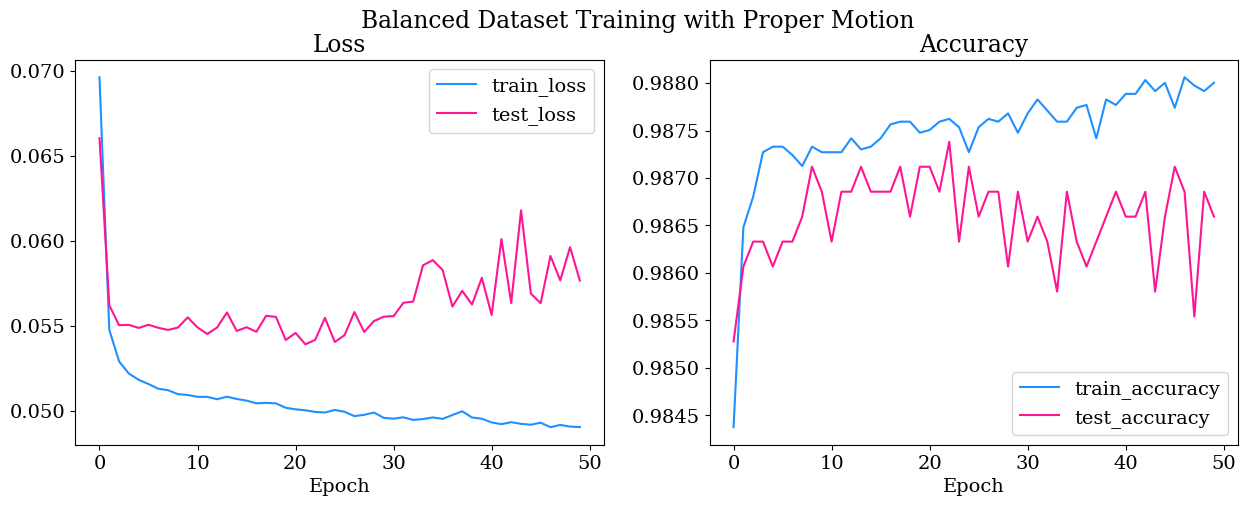

<Figure size 640x480 with 0 Axes>

In [56]:
# Plot loss and accuracy in subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Balanced Dataset Training with Proper Motion')
ax1.set_title('Loss')
ax2.set_title('Accuracy')
colors = {
    'train': 'dodgerblue',
    'test': 'deeppink'
}
for dataset in ('train','test'):
  ax1.plot(metrics_history[f'{dataset}_loss'], label=f'{dataset}_loss', color=colors[dataset])
  ax2.plot(metrics_history[f'{dataset}_accuracy'], label=f'{dataset}_accuracy', color=colors[dataset])
ax1.set_xlabel('Epoch')
ax2.set_xlabel('Epoch')
ax1.legend()
ax2.legend()
plt.show()
plt.clf()

In [57]:
@jax.jit
def pred_step(state, batch):
  logits = state.apply_fn({'params': state.params}, batch)
  return logits.argmax(axis=1)

pred = pred_step(state, X_tst)
pred

Array([0, 1, 0, ..., 1, 1, 0], dtype=int32)

(array([1863.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
        1941.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

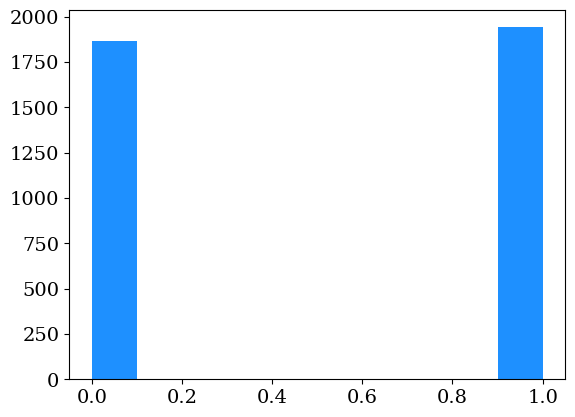

In [58]:
plt.hist(pred, color='dodgerblue')

(-100.0, 10.0)

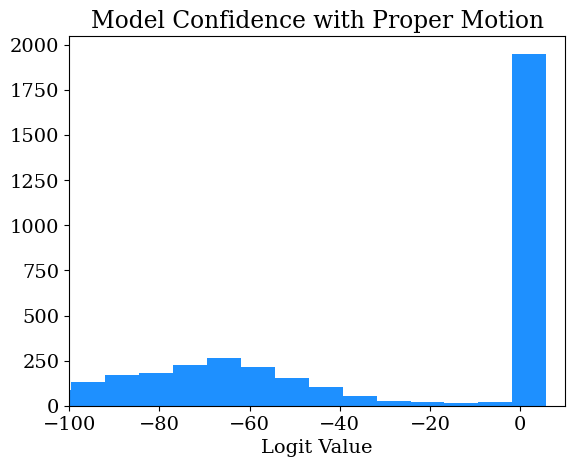

In [59]:
outputs = state.apply_fn({'params': state.params}, X_tst)
plt.hist(jnp.diff(outputs, axis=1).flatten(), color='dodgerblue', bins=50);
plt.title('Model Confidence with Proper Motion')
plt.xlabel('Logit Value')
plt.xlim(-100,10)

In [60]:
logit = jnp.diff(outputs, axis=1).flatten()
print('Number of positive logits:', jnp.sum(logit > 0))

Number of positive logits: 1941


In [61]:
ra_full  = df['ra'][~nans].to_numpy()
dec_full = df['dec'][~nans].to_numpy()

ra_m4 = np.array(ra_full[m4_mask])
ra_non = np.array(ra_full[non_mask])
ra_non = ra_non[idx]

dec_m4 = np.array(dec_full[m4_mask])
dec_non = np.array(dec_full[non_mask])
dec_non = dec_non[idx]

ra = np.concatenate((ra_m4, ra_non))
dec = np.concatenate((dec_m4, dec_non))

print(ra.shape, dec.shape)

(38038,) (38038,)


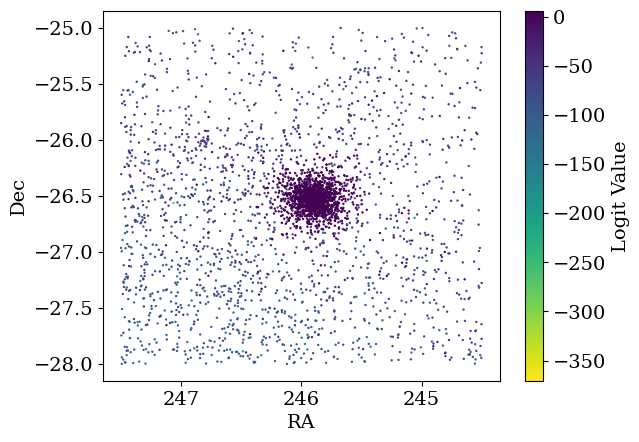

In [62]:
plt.scatter(ra[test_idx], dec[test_idx], c=jnp.diff(outputs, axis=1), s=0.5, cmap='viridis_r')
# plt.title('Balanced Dataset with Proper Motion')
plt.xlabel('RA')
plt.ylabel('Dec')
plt.gca().invert_xaxis()
plt.colorbar(label='Logit Value')

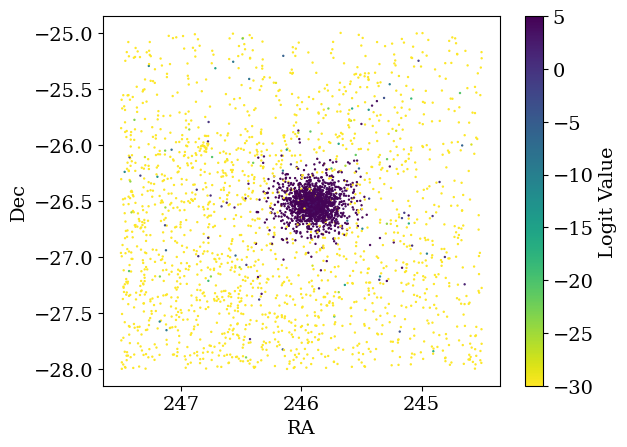

In [63]:
plt.scatter(ra[test_idx], dec[test_idx], c=jnp.diff(outputs, axis=1), s=0.5, cmap='viridis_r', vmin=-30, vmax=5)
# plt.title('Balanced Dataset with Proper Motion')
plt.xlabel('RA')
plt.ylabel('Dec')
plt.gca().invert_xaxis()
plt.colorbar(label='Logit Value')

Confusion Matrix:
 [[1856.   44.]
 [   7. 1897.]]


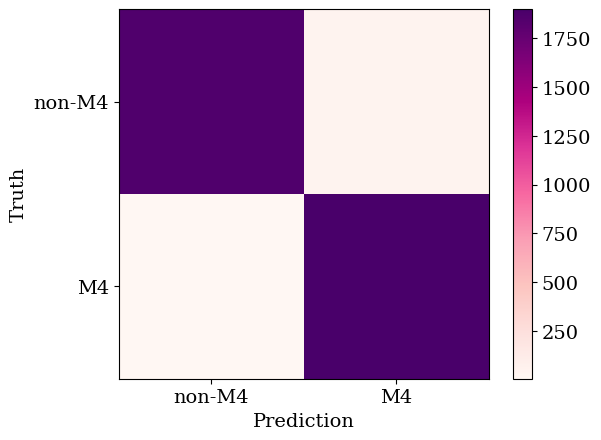

In [64]:
cm = check(state, X_tst, y_tst)

### Including Parallax

In [65]:
params = ['ra', 'dec', 'parallax']
X_full = np.array(df[params])
y_full = m4_sel.astype(int)

nans = np.any(np.isnan(X_full), axis=1)
X_full = X_full[~nans]
y_full = y_full[~nans]

m4_mask = y_full == 1
non_mask = y_full == 0

X_m4 = np.array(X_full[m4_mask])
y_m4 = np.array(y_full[m4_mask])
X_non = np.array(X_full[non_mask])
y_non = np.array(y_full[non_mask])

n = X_m4.shape[0]
idx = np.random.choice(X_non.shape[0], size=n, replace=False)

X_non = X_non[idx]
y_non = y_non[idx]

X = np.concatenate((X_m4, X_non))
y = np.concatenate((y_m4, y_non))

print(X.shape, y.shape)

(38038, 3) (38038,)


In [66]:
indices = np.arange(X.shape[0])
X_train, X_tst, y_train, y_tst, train_idx, test_idx = train_test_split(X, y, indices, test_size=0.1, shuffle=True, random_state=42)

In [67]:
transformer = StandardScaler()

X_train = transformer.fit_transform(X_train)
X_tst = transformer.transform(X_tst)

In [68]:
X_train = jnp.array(X_train)
X_tst = jnp.array(X_tst)
y_train = jnp.array(y_train)
y_tst = jnp.array(y_tst)

In [69]:
batch_size = 64
n_batches = X_train.shape[0] // batch_size

X_train = X_train[:n_batches * batch_size].reshape((n_batches, batch_size, *X_train.shape[1:]))
y_train = y_train[:n_batches * batch_size].reshape((n_batches, batch_size, *y_train.shape[1:]))
X_train.shape, y_train.shape

((534, 64, 3), (534, 64))

In [70]:
n_classes = 2

class DenseClassifier(nn.Module):
    """A simple dense classifier."""

    @nn.compact
    def __call__(self, x):
        x = nn.Dense(10)(x)
        x = nn.relu(x)
        x = nn.Dense(10)(x)
        x = nn.relu(x)
        x = nn.Dense(n_classes)(x)
        return x

In [71]:
dummy_input = jnp.ones((1, 3))
dnn = DenseClassifier()
print(dnn.tabulate(jax.random.PRNGKey(0), dummy_input))


                            DenseClassifier Summary                             
┏━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃ path    ┃ module          ┃ inputs        ┃ outputs       ┃ params           ┃
┡━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│         │ DenseClassifier │ float32[1,3]  │ float32[1,2]  │                  │
├─────────┼─────────────────┼───────────────┼───────────────┼──────────────────┤
│ Dense_0 │ Dense           │ float32[1,3]  │ float32[1,10] │ bias:            │
│         │                 │               │               │ float32[10]      │
│         │                 │               │               │ kernel:          │
│         │                 │               │               │ float32[3,10]    │
│         │                 │               │               │                  │
│         │                 │               │               │ 40 (160 B)       │
├─────────┼────────────────

In [72]:
X_train.shape, y_train.shape

((534, 64, 3), (534, 64))

In [73]:
@struct.dataclass
class Metrics(metrics.Collection):
    accuracy: metrics.Accuracy
    loss: metrics.Average.from_output('loss')

class TrainState(train_state.TrainState):
   metrics: Metrics

In [74]:
def create_train_state(model, rng, learning_rate):
    params = model.init(rng, dummy_input)['params']
    tx = optax.adam(learning_rate)
    return TrainState.create(
        apply_fn=model.apply, params=params, tx=tx,
        metrics=Metrics.empty())

In [75]:
@jax.jit
def train_step(state, batch, label):
  """Train for a single step."""
  def loss_fn(params):
    logits = state.apply_fn({'params': params}, batch)
    loss = optax.softmax_cross_entropy_with_integer_labels(
        logits=logits, labels=label).mean()
    return loss
  grad_fn = jax.grad(loss_fn)
  grads = grad_fn(state.params)
  state = state.apply_gradients(grads=grads)
  return state

In [76]:
@jax.jit
def compute_metrics(*, state, batch, label):
    logits = state.apply_fn({'params': state.params}, batch)
    loss = optax.softmax_cross_entropy_with_integer_labels(
        logits=logits, labels=label).mean()
    metric_updates = state.metrics.single_from_model_output(
        logits=logits, labels=label, loss=loss)
    metrics = state.metrics.merge(metric_updates)
    state = state.replace(metrics=metrics)
    return state

In [77]:
init_rng = jax.random.PRNGKey(0)

learning_rate = 0.01

state = create_train_state(dnn, init_rng, learning_rate)
del init_rng  # Must not be used anymore.

In [78]:
metrics_history = {'train_loss': [],
                   'train_accuracy': [],
                   'test_loss': [],
                   'test_accuracy': []}

In [79]:
n_epochs = 50

In [80]:
step = 0

for _ in range(n_epochs):
  for batch, label in zip(X_train, y_train):

    # Run optimization steps over training batches and compute batch metrics
    state = train_step(state, batch, label) # get updated train state (which contains the updated parameters)
    state = compute_metrics(state=state, batch=batch, label=label) # aggregate batch metrics

    if (step+1) % n_batches == 0: # one training epoch has passed
      for metric,value in state.metrics.compute().items(): # compute metrics
        metrics_history[f'train_{metric}'].append(value) # record metrics
      state = state.replace(metrics=state.metrics.empty()) # reset train_metrics for next training epoch

      # Compute metrics on the test set after each training epoch
      test_state = state
      test_state = compute_metrics(state=test_state, batch=X_tst, label=y_tst)

      for metric,value in test_state.metrics.compute().items():
        metrics_history[f'test_{metric}'].append(value)

      print(f"train epoch: {(step+1) // n_batches}, "
            f"loss: {metrics_history['train_loss'][-1]}, "
            f"accuracy: {metrics_history['train_accuracy'][-1] * 100}")
      print(f"test epoch: {(step+1) // n_batches}, "
            f"loss: {metrics_history['test_loss'][-1]}, "
            f"accuracy: {metrics_history['test_accuracy'][-1] * 100}")
    step += 1

train epoch: 1, loss: 0.1756247580051422, accuracy: 94.08649444580078
test epoch: 1, loss: 0.15236233174800873, accuracy: 94.400634765625
train epoch: 2, loss: 0.1505783498287201, accuracy: 94.82093048095703
test epoch: 2, loss: 0.14614780247211456, accuracy: 94.53207397460938
train epoch: 3, loss: 0.14825980365276337, accuracy: 94.9028549194336
test epoch: 3, loss: 0.14578869938850403, accuracy: 94.45320892333984
train epoch: 4, loss: 0.1471536010503769, accuracy: 94.9379653930664
test epoch: 4, loss: 0.14444227516651154, accuracy: 94.53207397460938
train epoch: 5, loss: 0.1467907577753067, accuracy: 94.95259857177734
test epoch: 5, loss: 0.14412818849086761, accuracy: 94.53207397460938
train epoch: 6, loss: 0.1465347558259964, accuracy: 94.98185729980469
test epoch: 6, loss: 0.1440599113702774, accuracy: 94.58464813232422
train epoch: 7, loss: 0.14620959758758545, accuracy: 94.9408950805664
test epoch: 7, loss: 0.14447490870952606, accuracy: 94.4794921875
train epoch: 8, loss: 0.1459

In [81]:
print('Mean training accuracy: %.3f' % np.mean(metrics_history['train_accuracy']))
print('Mean testing accuracy: %.3f' % np.mean(metrics_history['test_accuracy']))

Mean training accuracy: 0.950
Mean testing accuracy: 0.947


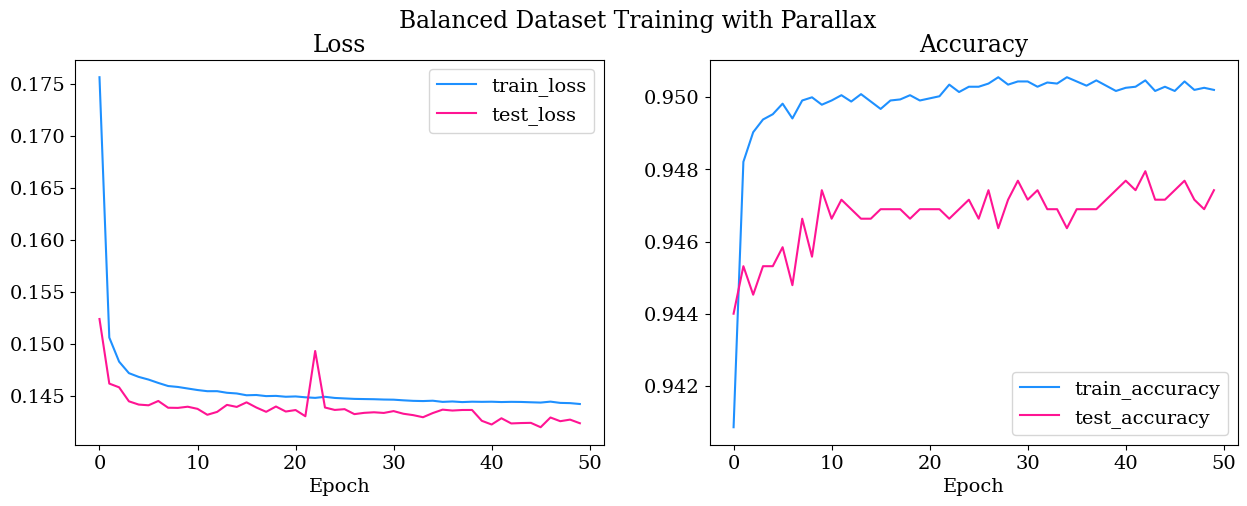

<Figure size 640x480 with 0 Axes>

In [82]:
# Plot loss and accuracy in subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Balanced Dataset Training with Parallax')
ax1.set_title('Loss')
ax2.set_title('Accuracy')
colors = {
    'train': 'dodgerblue',
    'test': 'deeppink'
}
for dataset in ('train','test'):
  ax1.plot(metrics_history[f'{dataset}_loss'], label=f'{dataset}_loss', color=colors[dataset])
  ax2.plot(metrics_history[f'{dataset}_accuracy'], label=f'{dataset}_accuracy', color=colors[dataset])
ax1.set_xlabel('Epoch')
ax2.set_xlabel('Epoch')
ax1.legend()
ax2.legend()
plt.show()
plt.clf()

In [83]:
@jax.jit
def pred_step(state, batch):
  logits = state.apply_fn({'params': state.params}, batch)
  return logits.argmax(axis=1)

pred = pred_step(state, X_tst)
pred

Array([0, 1, 0, ..., 1, 1, 0], dtype=int32)

(array([1834.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
        1970.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

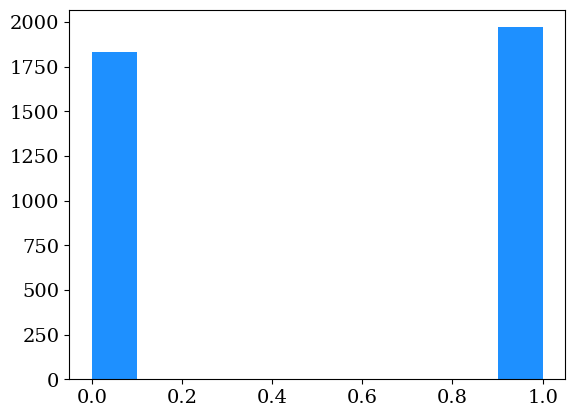

In [84]:
plt.hist(pred, color='dodgerblue')

(-15.0, 6.0)

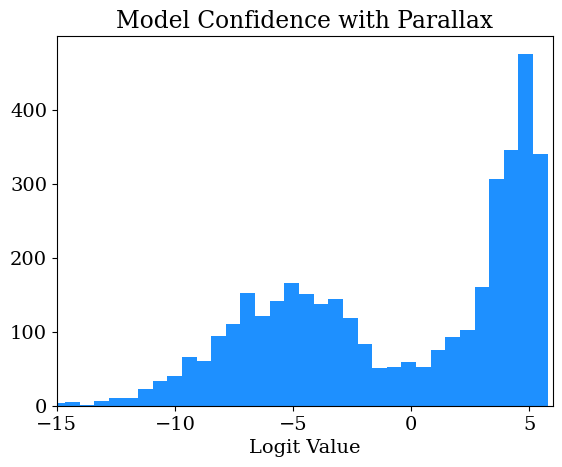

In [85]:
outputs = state.apply_fn({'params': state.params}, X_tst)
plt.hist(jnp.diff(outputs, axis=1).flatten(), color='dodgerblue', bins=50);
plt.title('Model Confidence with Parallax')
plt.xlabel('Logit Value')
plt.xlim(-15,6)

In [86]:
logit = jnp.diff(outputs, axis=1).flatten()
print('Number of positive logits:', jnp.sum(logit > 0))

Number of positive logits: 1970


In [87]:
ra_full  = df['ra'][~nans].to_numpy()
dec_full = df['dec'][~nans].to_numpy()

ra_m4 = np.array(ra_full[m4_mask])
ra_non = np.array(ra_full[non_mask])
ra_non = ra_non[idx]

dec_m4 = np.array(dec_full[m4_mask])
dec_non = np.array(dec_full[non_mask])
dec_non = dec_non[idx]

ra = np.concatenate((ra_m4, ra_non))
dec = np.concatenate((dec_m4, dec_non))

print(ra.shape, dec.shape)

(38038,) (38038,)


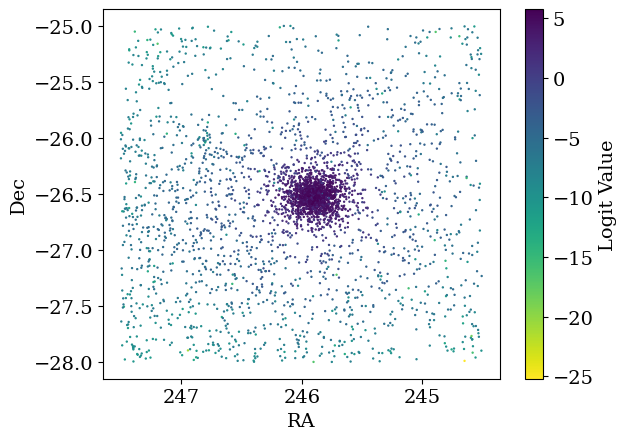

In [88]:
plt.scatter(ra[test_idx], dec[test_idx], c=jnp.diff(outputs, axis=1), s=0.5, cmap='viridis_r')
# plt.title('Balanced Dataset with Parallax')
plt.xlabel('RA')
plt.ylabel('Dec')
plt.gca().invert_xaxis()
plt.colorbar(label='Logit Value')

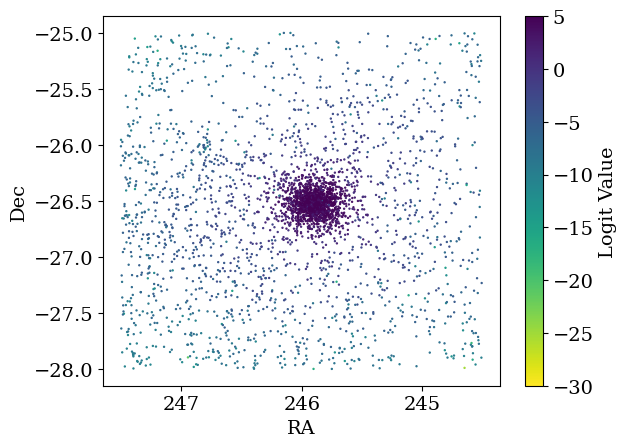

In [89]:
plt.scatter(ra[test_idx], dec[test_idx], c=jnp.diff(outputs, axis=1), s=0.5, cmap='viridis_r', vmin=-30, vmax=5)
# plt.title('Balanced Dataset with Parallax')
plt.xlabel('RA')
plt.ylabel('Dec')
plt.gca().invert_xaxis()
plt.colorbar(label='Logit Value')

Confusion Matrix:
 [[1767.  133.]
 [  67. 1837.]]


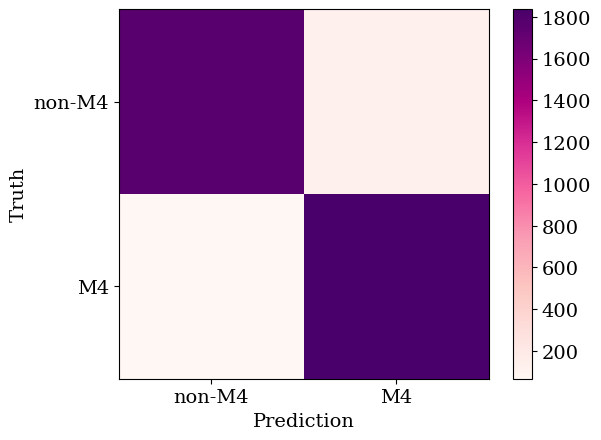

In [90]:
cm = check(state, X_tst, y_tst)

### Including Both

In [91]:
params = ['ra', 'dec', 'parallax', 'pmra', 'pmdec']
X_full = np.array(df[params])
y_full = m4_sel.astype(int)

nans = np.any(np.isnan(X_full), axis=1)
X_full = X_full[~nans]
y_full = y_full[~nans]

m4_mask = y_full == 1
non_mask = y_full == 0

X_m4 = np.array(X_full[m4_mask])
y_m4 = np.array(y_full[m4_mask])
X_non = np.array(X_full[non_mask])
y_non = np.array(y_full[non_mask])

n = X_m4.shape[0]
idx = np.random.choice(X_non.shape[0], size=n, replace=False)

X_non = X_non[idx]
y_non = y_non[idx]

X = np.concatenate((X_m4, X_non))
y = np.concatenate((y_m4, y_non))

print(X.shape, y.shape)

(38038, 5) (38038,)


In [92]:
indices = np.arange(X.shape[0])
X_train, X_tst, y_train, y_tst, train_idx, test_idx = train_test_split(X, y, indices, test_size=0.1, shuffle=True, random_state=42)

In [93]:
transformer = StandardScaler()

X_train = transformer.fit_transform(X_train)
X_tst = transformer.transform(X_tst)

In [94]:
X_train = jnp.array(X_train)
X_tst = jnp.array(X_tst)
y_train = jnp.array(y_train)
y_tst = jnp.array(y_tst)

In [95]:
batch_size = 64
n_batches = X_train.shape[0] // batch_size

X_train = X_train[:n_batches * batch_size].reshape((n_batches, batch_size, *X_train.shape[1:]))
y_train = y_train[:n_batches * batch_size].reshape((n_batches, batch_size, *y_train.shape[1:]))
X_train.shape, y_train.shape

((534, 64, 5), (534, 64))

In [96]:
n_classes = 2

class DenseClassifier(nn.Module):
    """A simple dense classifier."""

    @nn.compact
    def __call__(self, x):
        x = nn.Dense(10)(x)
        x = nn.relu(x)
        x = nn.Dense(10)(x)
        x = nn.relu(x)
        x = nn.Dense(n_classes)(x)
        return x

In [97]:
dummy_input = jnp.ones((1, 5))
dnn = DenseClassifier()
print(dnn.tabulate(jax.random.PRNGKey(0), dummy_input))


                            DenseClassifier Summary                             
┏━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┓
┃ path    ┃ module          ┃ inputs        ┃ outputs       ┃ params           ┃
┡━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━┩
│         │ DenseClassifier │ float32[1,5]  │ float32[1,2]  │                  │
├─────────┼─────────────────┼───────────────┼───────────────┼──────────────────┤
│ Dense_0 │ Dense           │ float32[1,5]  │ float32[1,10] │ bias:            │
│         │                 │               │               │ float32[10]      │
│         │                 │               │               │ kernel:          │
│         │                 │               │               │ float32[5,10]    │
│         │                 │               │               │                  │
│         │                 │               │               │ 60 (240 B)       │
├─────────┼────────────────

In [98]:
X_train.shape, y_train.shape

((534, 64, 5), (534, 64))

In [99]:
@struct.dataclass
class Metrics(metrics.Collection):
    accuracy: metrics.Accuracy
    loss: metrics.Average.from_output('loss')

class TrainState(train_state.TrainState):
   metrics: Metrics

In [100]:
def create_train_state(model, rng, learning_rate):
    params = model.init(rng, dummy_input)['params']
    tx = optax.adam(learning_rate)
    return TrainState.create(
        apply_fn=model.apply, params=params, tx=tx,
        metrics=Metrics.empty())

In [101]:
@jax.jit
def train_step(state, batch, label):
  """Train for a single step."""
  def loss_fn(params):
    logits = state.apply_fn({'params': params}, batch)
    loss = optax.softmax_cross_entropy_with_integer_labels(
        logits=logits, labels=label).mean()
    return loss
  grad_fn = jax.grad(loss_fn)
  grads = grad_fn(state.params)
  state = state.apply_gradients(grads=grads)
  return state

In [102]:
@jax.jit
def compute_metrics(*, state, batch, label):
    logits = state.apply_fn({'params': state.params}, batch)
    loss = optax.softmax_cross_entropy_with_integer_labels(
        logits=logits, labels=label).mean()
    metric_updates = state.metrics.single_from_model_output(
        logits=logits, labels=label, loss=loss)
    metrics = state.metrics.merge(metric_updates)
    state = state.replace(metrics=metrics)
    return state

In [103]:
init_rng = jax.random.PRNGKey(0)

learning_rate = 0.01

state = create_train_state(dnn, init_rng, learning_rate)
del init_rng  # Must not be used anymore.

In [104]:
metrics_history = {'train_loss': [],
                   'train_accuracy': [],
                   'test_loss': [],
                   'test_accuracy': []}

In [105]:
n_epochs = 50

In [106]:
step = 0

for _ in range(n_epochs):
  for batch, label in zip(X_train, y_train):

    # Run optimization steps over training batches and compute batch metrics
    state = train_step(state, batch, label) # get updated train state (which contains the updated parameters)
    state = compute_metrics(state=state, batch=batch, label=label) # aggregate batch metrics

    if (step+1) % n_batches == 0: # one training epoch has passed
      for metric,value in state.metrics.compute().items(): # compute metrics
        metrics_history[f'train_{metric}'].append(value) # record metrics
      state = state.replace(metrics=state.metrics.empty()) # reset train_metrics for next training epoch

      # Compute metrics on the test set after each training epoch
      test_state = state
      test_state = compute_metrics(state=test_state, batch=X_tst, label=y_tst)

      for metric,value in test_state.metrics.compute().items():
        metrics_history[f'test_{metric}'].append(value)

      print(f"train epoch: {(step+1) // n_batches}, "
            f"loss: {metrics_history['train_loss'][-1]}, "
            f"accuracy: {metrics_history['train_accuracy'][-1] * 100}")
      print(f"test epoch: {(step+1) // n_batches}, "
            f"loss: {metrics_history['test_loss'][-1]}, "
            f"accuracy: {metrics_history['test_accuracy'][-1] * 100}")
    step += 1

train epoch: 1, loss: 0.06743650883436203, accuracy: 98.39653015136719
test epoch: 1, loss: 0.04623342677950859, accuracy: 98.65930938720703
train epoch: 2, loss: 0.050022583454847336, accuracy: 98.67742919921875
test epoch: 2, loss: 0.04362863302230835, accuracy: 98.73816680908203
train epoch: 3, loss: 0.04814854636788368, accuracy: 98.70084381103516
test epoch: 3, loss: 0.043647393584251404, accuracy: 98.7907485961914
train epoch: 4, loss: 0.04733177646994591, accuracy: 98.7125473022461
test epoch: 4, loss: 0.04300590604543686, accuracy: 98.73816680908203
train epoch: 5, loss: 0.046827532351017, accuracy: 98.74180603027344
test epoch: 5, loss: 0.043798547238111496, accuracy: 98.76445770263672
train epoch: 6, loss: 0.04640491306781769, accuracy: 98.75643920898438
test epoch: 6, loss: 0.04368225112557411, accuracy: 98.73816680908203
train epoch: 7, loss: 0.04627818241715431, accuracy: 98.74473571777344
test epoch: 7, loss: 0.042975228279829025, accuracy: 98.71188354492188
train epoch: 

In [107]:
print('Mean training accuracy: %.3f' % np.mean(metrics_history['train_accuracy']))
print('Mean testing accuracy: %.3f' % np.mean(metrics_history['test_accuracy']))

Mean training accuracy: 0.988
Mean testing accuracy: 0.987


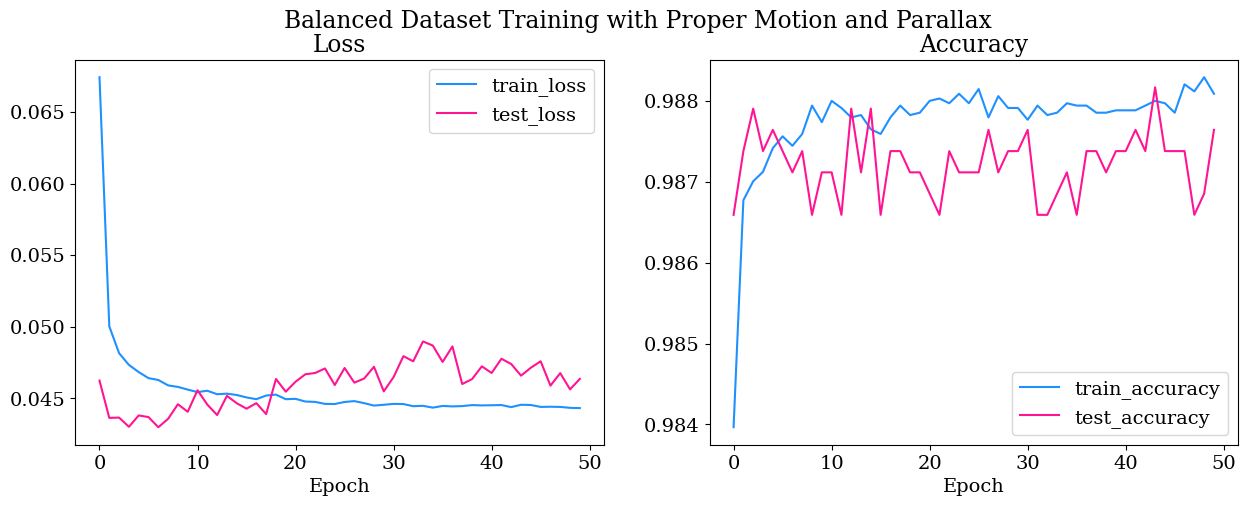

<Figure size 640x480 with 0 Axes>

In [108]:
# Plot loss and accuracy in subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Balanced Dataset Training with Proper Motion and Parallax')
ax1.set_title('Loss')
ax2.set_title('Accuracy')
colors = {
    'train': 'dodgerblue',
    'test': 'deeppink'
}
for dataset in ('train','test'):
  ax1.plot(metrics_history[f'{dataset}_loss'], label=f'{dataset}_loss', color=colors[dataset])
  ax2.plot(metrics_history[f'{dataset}_accuracy'], label=f'{dataset}_accuracy', color=colors[dataset])
ax1.set_xlabel('Epoch')
ax2.set_xlabel('Epoch')
ax1.legend()
ax2.legend()
plt.show()
plt.clf()

In [109]:
@jax.jit
def pred_step(state, batch):
  logits = state.apply_fn({'params': state.params}, batch)
  return logits.argmax(axis=1)

pred = pred_step(state, X_tst)
pred

Array([0, 1, 0, ..., 1, 1, 0], dtype=int32)

(array([1869.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
        1935.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

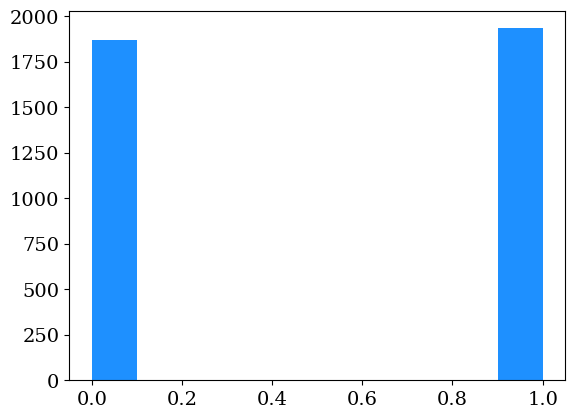

In [110]:
plt.hist(pred, color='dodgerblue')

(-100.0, 10.0)

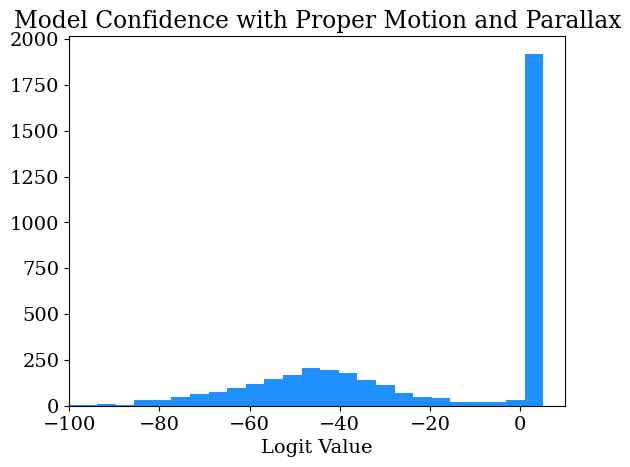

In [118]:
outputs = state.apply_fn({'params': state.params}, X_tst)
plt.hist(jnp.diff(outputs, axis=1).flatten(), color='dodgerblue', bins=50);
plt.title('Model Confidence with Proper Motion and Parallax')
plt.xlabel('Logit Value')
plt.xlim(-100, 10)

In [112]:
logit = jnp.diff(outputs, axis=1).flatten()
print('Number of positive logits:', jnp.sum(logit > 0))

Number of positive logits: 1935


In [113]:
ra_full  = df['ra'][~nans].to_numpy()
dec_full = df['dec'][~nans].to_numpy()

ra_m4 = np.array(ra_full[m4_mask])
ra_non = np.array(ra_full[non_mask])
ra_non = ra_non[idx]

dec_m4 = np.array(dec_full[m4_mask])
dec_non = np.array(dec_full[non_mask])
dec_non = dec_non[idx]

ra = np.concatenate((ra_m4, ra_non))
dec = np.concatenate((dec_m4, dec_non))

print(ra.shape, dec.shape)

(38038,) (38038,)


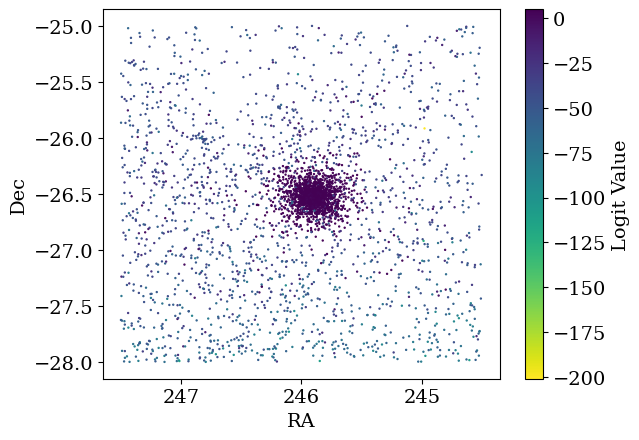

In [114]:
plt.scatter(ra[test_idx], dec[test_idx], c=jnp.diff(outputs, axis=1), s=0.5, cmap='viridis_r')
# plt.title('Balanced Dataset with Proper Motion and Parallax')
plt.xlabel('RA')
plt.ylabel('Dec')
plt.gca().invert_xaxis()
plt.colorbar(label='Logit Value')

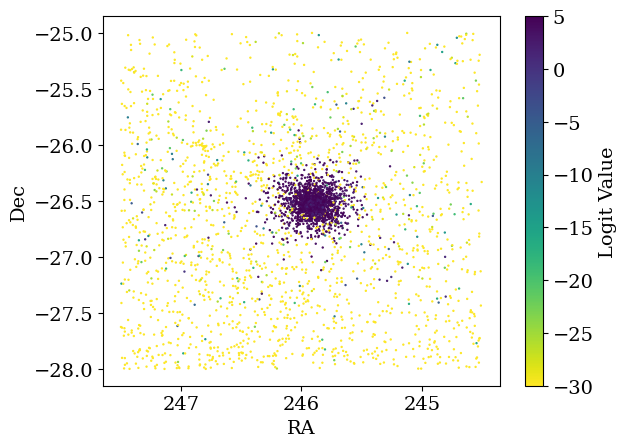

In [115]:
plt.scatter(ra[test_idx], dec[test_idx], c=jnp.diff(outputs, axis=1), s=0.5, cmap='viridis_r', vmin=-30, vmax=5)
# plt.title('Balanced Dataset with Proper Motion and Parallax')
plt.xlabel('RA')
plt.ylabel('Dec')
plt.gca().invert_xaxis()
plt.colorbar(label='Logit Value')

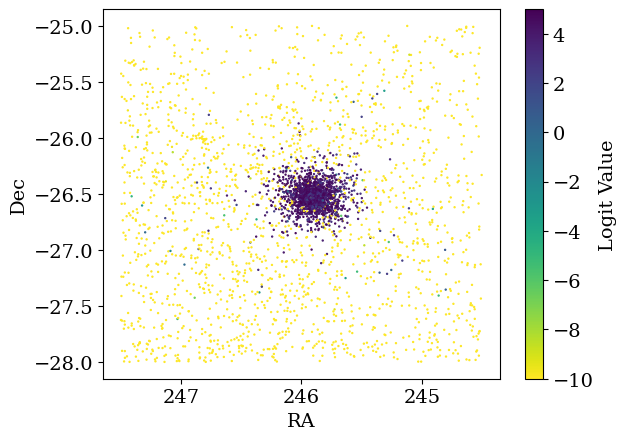

In [121]:
plt.scatter(ra[test_idx], dec[test_idx], c=jnp.diff(outputs, axis=1), s=0.5, cmap='viridis_r', vmin=-10, vmax=5)
# plt.title('Balanced Dataset with Proper Motion and Parallax')
plt.xlabel('RA')
plt.ylabel('Dec')
plt.gca().invert_xaxis()
plt.colorbar(label='Logit Value')

Confusion Matrix:
 [[1861.   39.]
 [   8. 1896.]]


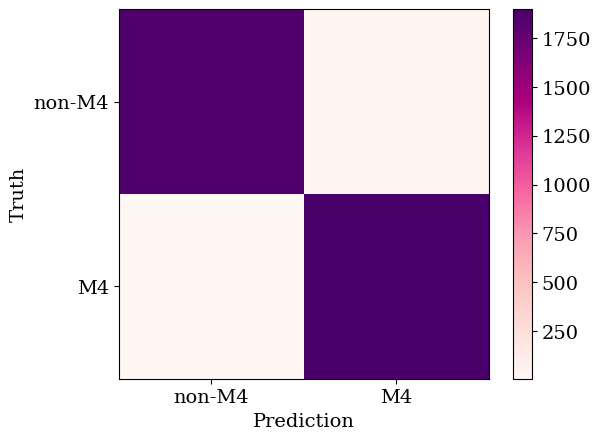

In [116]:
cm = check(state, X_tst, y_tst)

In [117]:
# Generated using ChatGPT

# logits for the balanced dataset
logits = state.apply_fn({'params': state.params}, X)
m4_logits = logits[:, 1]  # class 1 = M4

# confident predictions
confidence_threshold = 0.0
confident_mask = m4_logits > confidence_threshold

# m4_mask for the balanced dataset
m4_mask_np = np.array(y == 1)
new_m4_mask = confident_mask & (~m4_mask_np)

confident_indices = jnp.argsort(-m4_logits[new_m4_mask])
ra_new = ra[new_m4_mask][confident_indices]
dec_new = dec[new_m4_mask][confident_indices]
logit_values = m4_logits[new_m4_mask][confident_indices]

top_N = 20
ra_top = ra_new[:top_N]
dec_top = dec_new[:top_N]
logits_top = logit_values[:top_N]

print(f"Found {new_m4_mask.sum()} new M4 candidates")

Found 0 new M4 candidates
